# Simplified PSID pipeline (single session, DBS=both)

Goal: end-to-end exploration in one notebook —
1. Load one session's trials (ECoG candidates + behavioural targets + DBS labels).
2. mRMR feature selection on ECoG, target = DBS state (`feature_engine.MRMR`).
3. Train PSID on selected channels.
4. One-step prediction + multi-step forecast on val/test.
5. DBS on/off classification on PSID latents (LDA).

Compared to `training/pipelines/psid.py`:
- No subprocess phases, no YAML configs, no on/off split models.
- Single mRMR pass instead of cached `mrmr_picks.yaml`.
- In-process LDA only — no permutations, no h×m grid, no `Xp_with_dbs` flavours.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/bobby/repos/latent-neural-dynamics-modeling")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import copy
import time
import numpy as np
import pandas as pd
import polars as pl
import yaml
import matplotlib.pyplot as plt
from feature_engine.selection import MRMR
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
import PSID
from PSID.PSID import fitCzViaKFRegression
from utils.frameworks import PSIDWrapper
from utils.classification.splits import ChronoGroupsSplit
from utils.stats import pearson_r_per_channel
from utils.classification.pipeline import create_pipeline

## Knobs

In [2]:
PARTICIPANT = "PDI1"
SESSION = "2"
SFREQ = 200

DATASET_TAG = "participants_at_200Hz_scaled_1e6_raw_envelope"
DATA_ROOT = PROJECT_ROOT / "resampled_recordings" / DATASET_TAG
SESSION_PATH = DATA_ROOT / f"participant_id={PARTICIPANT}" / f"session={SESSION}"

# 200 Hz output, 17 narrow-band freq ranges × {raw, env} = 34 feature names.
# Gap [47, 53] around 50 Hz mains. Bands stop at 93 (Nyquist margin + skip
# 100 Hz harmonic).
_BAND_FREQS = [
    ("theta_4_8", [4, 8]),
    ("alpha_8_12", [8, 12]),
    ("beta_13_18", [13, 18]),
    ("beta_18_23", [18, 23]),
    ("beta_23_28", [23, 28]),
    ("beta_28_32", [28, 32]),
    ("gamma_32_37", [32, 37]),
    ("gamma_37_42", [37, 42]),
    ("gamma_42_47", [42, 47]),
    ("gamma_53_58", [53, 58]),
    ("gamma_58_63", [58, 63]),
    ("gamma_63_68", [63, 68]),
    ("gamma_68_73", [68, 73]),
    ("gamma_73_78", [73, 78]),
    ("gamma_78_83", [78, 83]),
    ("gamma_83_88", [83, 88]),
    ("gamma_88_93", [88, 93]),
]
BANDS = [f"{name}_{suf}" for name, _ in _BAND_FREQS for suf in ("raw", "env")]
BEHAVIOR_COLS = ["tracing_velocity_x", "tracing_acceleration_magnitude"]
LAP_PAIRS_9_16 = ["9-11", "10-12", "11-13", "12-14", "13-15", "14-16"]
ECOG_COLS = [f"ECOG_{e}_{b}" for e in range(1, 5) for b in BANDS]
LAP_COLS = [f"LAPLACIAN_{p}_LFP_{b}" for p in LAP_PAIRS_9_16 for b in BANDS]

# Y source: "ecog" — ECoG bands (default Sani et al. setup, neural input).
#           "behavior" — Y = [velocity_x, acceleration_magnitude]. State driven
#           by behavior; predict ECoG/LFP as Z. Useful to test the reverse:
#           how much behavioral dynamics predict cortical activity.
Y_SOURCE = "ecog"
RAW_BANDS_ONLY = False
RAW_BAND_NAMES = set(BANDS)  # all 200 Hz bands are already raw

# Z source:
#   "laplacian" — cross-decode neural → LFP laplacian.
#   "ecog_self" — Z = Y candidates (PSID self-decode on Y).
#   "behavior"  — Z = behavior cols (Sani et al. original setup).
#   "ecog"      — Z = ECoG bands (use when Y_SOURCE="behavior" to flip roles).
Z_SOURCE = "laplacian"

if Y_SOURCE == "ecog":
    Y_CANDIDATES = list(ECOG_COLS)
elif Y_SOURCE == "behavior":
    Y_CANDIDATES = list(BEHAVIOR_COLS)
else:
    raise ValueError(f"unknown Y_SOURCE={Y_SOURCE}")

if Y_SOURCE == "ecog" and RAW_BANDS_ONLY:
    Y_CANDIDATES = [c for c in Y_CANDIDATES if c.split("_", 2)[-1] in RAW_BAND_NAMES]
    print(f"  RAW_BANDS_ONLY filter → {len(Y_CANDIDATES)} Y candidates")

if Z_SOURCE == "laplacian":
    Z_CANDIDATES = list(LAP_COLS)
elif Z_SOURCE == "ecog_self":
    Z_CANDIDATES = list(Y_CANDIDATES)
elif Z_SOURCE == "behavior":
    Z_CANDIDATES = list(BEHAVIOR_COLS)
elif Z_SOURCE == "ecog":
    Z_CANDIDATES = list(ECOG_COLS)
else:
    raise ValueError(f"unknown Z_SOURCE={Z_SOURCE}")
print(f"Y candidates (ECoG): {len(Y_CANDIDATES)}")
print(f"Z candidates ({Z_SOURCE}): {len(Z_CANDIDATES)}")

K_Y = 12  # K=12 with raw/env stratification → 6 raw + 6 env each modality
K_Z = 12
K_Y_INT = 40  # intermediate pool after stage-1 MRMR for Y
K_Z_INT = 30  # intermediate pool after stage-1 MRMR for Z


# Toggle 2-stage mRMR feature selection. False ⇒ all 96 ECoG / all 144 LAP
# channels go straight into PSID (no cross-corr stage 1, no DBS-FCQ stage 2,
# no raw-corr cleanup). Used to compare mRMR-vs-no-mRMR head-to-head at the
# same (nx, n1).
USE_MRMR = True

# Y selection criterion (when USE_MRMR=True and Y_SOURCE="ecog"):
#   "mrmr_dbs_2stage" — 2-stage mRMR: cross-corr Y↔Z (same-band) → FCQ-DBS.
#                        Picks Y features that are DBS-discriminative AND
#                        cross-modality correlated with Z partners. Best when
#                        you want PSID's Cz (Y→Z) to have signal to fit.
#   "mrmr_dbs"        — single-stage mRMR FCQ-DBS on the full pool.
#                        F-stat relevance ÷ Pearson redundancy. No Y-Z
#                        coupling check — picks pure DBS-relevance.
#   "forecastability" — AR(2) train r² per channel. CAREFUL: biases toward
#                        smooth envelopes and gives VARMA an unfair head start
#                        in baselining. Kept for diagnostic only.
Y_SELECTION = "mrmr_dbs"

# CV-stabilized selection: run mRMR-FCQ-DBS over CV_FOLDS folds of train,
# aggregate by frequency of appearance. CV_FOLDS=1 ⇒ single-pass (legacy).
CV_FOLDS = 5

# Stratify by feature mode (raw vs env): take K_Y/2 of each. Enforces
# mixture so neither mode dominates the pool. Set False for free competition.
STRATIFY_RAW_ENV = True

# RAW_BANDS_ONLY + RAW_BAND_NAMES are defined above (with the Y_SOURCE knob)
# so the candidate-pool dispatch sees them. Edit those values directly.

# nx/n1 picked by val-fold cross-validated CC (Sani et al protocol, single-fold
# variant — see "nx/n1 selection" cell below). Set USE_CV_SELECTION=False to
# fall back on configs/diagnostic/elbow_choices.yaml.
USE_CV_SELECTION = True
# Grid search (selection by val forecast r — see SELECTION_BY below).
# Grid walks ascending; plateau-stop kicks in when next val r drops below
# running max − PLATEAU_TOL → "improve until it stops improving" rule.
NX_GRID = [50]
N1_GRID = [2, 4, 8]

# Sweep selection metric:
#   "cc_pred"          — Sani 1-step CC (Y self-pred CC for nx, Z decoding CC
#                        for n1) — original parsimony rule.
#   "forecast_pearson" — val Y forecast r (per-trial-feat Pearson) for nx,
#                        val Z forecast r for n1. Aligns selection with
#                        forecast goal directly.
SELECTION_BY = "forecast_pearson"

# Plateau parsimony rule (Sani et al, single-fold): stop when CC drops below
# running max - tol; pick smallest k within tol of best.
PLATEAU_TOL = 0.005
# i (PSID horizon) — 20 Hz ⇒ 8 samples = 400 ms physical horizon. With K_Y=8
# and K_Z=8: i*ny = i*nz = 64 ≥ max(nx)=60 ✓ and ≥ max(n1)=20 ✓.
I_HORIZON = 100
SKIP_CZ_KALMAN_REFIT = True  # use LS-on-Xk Cz only; skip post-DARE Kalman refit
MAX_EIG = 0.996  # clip A eigenvalues so DARE refit succeeds (scipy 1.16 needs e=None)

# Fallback elbow values (used if USE_CV_SELECTION=False or CV fails).
elbow_path = PROJECT_ROOT / "configs" / "diagnostic" / "elbow_choices.yaml"
elbow = yaml.safe_load(elbow_path.read_text())
elbow_rec = elbow["sessions"][f"{PARTICIPANT}_S{SESSION}"]["laplacian"]
NX_FALLBACK = int(elbow_rec["nx"])
N1_FALLBACK = int(elbow_rec["n1"])
HISTORY_S = 2.0
FORECAST_S = 1.0
EPOCH_LEN_S = 0.5
EPOCH_OVERLAP = 0.25

split_path = PROJECT_ROOT / "configs" / "splits" / f"{PARTICIPANT}_S{SESSION}.yaml"
split_cfg = yaml.safe_load(split_path.read_text())
TRAIN_BLOCKS = set(split_cfg["train_blocks"])
VAL_BLOCKS = set(split_cfg["val_blocks"])
TEST_BLOCKS = set(split_cfg["test_blocks"])
print(
    f"split blocks  train={sorted(TRAIN_BLOCKS)}  val={sorted(VAL_BLOCKS)}  test={sorted(TEST_BLOCKS)}"
)

Y candidates (ECoG): 136
Z candidates (laplacian): 204
split blocks  train=[1, 2, 3, 4, 5, 6]  val=[7, 8]  test=[9, 10, 11, 12]


## Load session → list of trial dicts

Each trial row in parquet stores per-channel signals as `List[Float]`. Both
ECoG and laplacian LFP columns carry `chunk_margin` seconds of pre/post
padding (length n). After symmetric trim they are identical length, no
alignment needed.

In [3]:
def load_session_trials(session_path, y_cols, z_cols, sfreq):
    rows = []
    for bf in sorted(session_path.glob("block=*/0.parquet")):
        block_num = int(bf.parent.name.split("=")[1])
        df = pl.read_parquet(bf)
        for i in range(len(df)):
            r = df[i]
            cm_ts = int(round(float(r["chunk_margin"][0]) * sfreq))
            Y_full = np.column_stack(
                [np.asarray(r[c][0], dtype=np.float64) for c in y_cols]
            )
            Z_full = np.column_stack(
                [np.asarray(r[c][0], dtype=np.float64) for c in z_cols]
            )
            n_y = Y_full.shape[0]
            n_z = Z_full.shape[0]
            # ECoG/LAP cols carry chunk_margin pre/post pad → trim. Behavior
            # cols (tracing_*) are interpolated to original_length_ts only
            # (no margin) → leave as-is. Detect via length match against Y.
            y_trim = Y_full[cm_ts : n_y - cm_ts]
            z_trim = Z_full[cm_ts : n_z - cm_ts] if n_z == n_y else Z_full
            # Harmonize: rounding in time_original vs band sample count can
            # introduce 1-sample drift between behavior and ECoG. Truncate to
            # common length so PSID sees aligned (Y_t, Z_t).
            T = min(y_trim.shape[0], z_trim.shape[0])
            y_trim = y_trim[:T]
            z_trim = z_trim[:T]
            rows.append(
                {
                    "block": block_num,
                    "trial": int(r["trial"][0]),
                    "stim": r["stim"][0],
                    "Y": y_trim,
                    "Z": z_trim,
                }
            )
    return rows


trials = load_session_trials(SESSION_PATH, Y_CANDIDATES, Z_CANDIDATES, SFREQ)

# (Block-level z-score was tried and removed: each block is pure DBS-on or
# pure DBS-off, so per-block mean removal *zeros out* the inter-block DBS
# signature → classification crashed to chance and forecast first-0.1s r
# halved. PSID's internal zscore_Y=True over the whole train pool keeps
# the block differences and is the right default.)

n_on = sum(t["stim"] == "on" for t in trials)
n_off = sum(t["stim"] == "off" for t in trials)
print(f"loaded {len(trials)} trials  (on={n_on}, off={n_off})")
print(
    f"first trial: Y.shape={trials[0]['Y'].shape}, Z.shape={trials[0]['Z'].shape}, stim={trials[0]['stim']}"
)

loaded 144 trials  (on=72, off=72)
first trial: Y.shape=(1800, 136), Z.shape=(1800, 204), stim=off


## Block-level split (canonical, from `configs/splits/{P}_S{S}.yaml`)

In [4]:
train_trials = [t for t in trials if t["block"] in TRAIN_BLOCKS]
val_trials = [t for t in trials if t["block"] in VAL_BLOCKS]
test_trials = [t for t in trials if t["block"] in TEST_BLOCKS]
for name, ts in (("train", train_trials), ("val", val_trials), ("test", test_trials)):
    on = sum(t["stim"] == "on" for t in ts)
    off = sum(t["stim"] == "off" for t in ts)
    print(f"{name}: n={len(ts)}  on={on}  off={off}")

train: n=72  on=36  off=36
val: n=24  on=12  off=12
test: n=48  on=24  off=24


## Feature selection — pairwise cross-corr → FCQ vs DBS

Per-trial log(std) per channel = log-RMS = canonical band-power proxy for
narrow-band zero-mean signals. Shape: 48 rows (trials) × 60 (Y) / 90 (Z).

**Stage 1 — cross-modality via pairwise correlation on RAW waveforms:**
  For each Y candidate i, score = `max_j |corr(Y_i_raw, Z_j_raw)|` over all
  train samples (concatenated, block-demeaned). Same-band constraint. Raw
  narrow-band coupling = exactly what PSID linear Cz can recover, unlike
  log-power coupling (which is squared envelope and non-linear).

**Stage 2 — DBS separability:**
  `MRMR(method="FCQ", regression=False)` on stage-1 survivors. F-statistic
  (ANOVA F) for class separation, Pearson redundancy, quotient scheme.
  F-stat is the linear measure of how well a feature splits on/off groups —
  matches PSID's linearity assumption better than RF importance.

In [5]:
Y_train_agg = np.stack([np.log(np.std(t["Y"], axis=0) + 1e-12) for t in train_trials])
Z_train_agg = np.stack([np.log(np.std(t["Z"], axis=0) + 1e-12) for t in train_trials])
trial_labels = np.array(
    [1 if t["stim"] == "on" else 0 for t in train_trials], dtype=np.int64
)
# Stage-1 operates on raw narrow-band waveforms (matches PSID's linear
# input space). Stage-2 stays on per-trial log-power (DBS label is per-trial).
Y_train_raw = np.concatenate([t["Y"] for t in train_trials], axis=0)
Z_train_raw = np.concatenate([t["Z"] for t in train_trials], axis=0)
sample_blocks = np.concatenate(
    [np.full(t["Y"].shape[0], t["block"], dtype=np.int64) for t in train_trials]
)
print(
    f"trial-aggregate shape: Y={Y_train_agg.shape}  Z={Z_train_agg.shape}  labels={trial_labels.shape}"
)
print(
    f"raw-concat shape: Y={Y_train_raw.shape}  Z={Z_train_raw.shape}  samples_per_block={np.bincount(sample_blocks)[sample_blocks.min():]}"
)

K_Y_INT_eff = min(K_Y_INT, len(Y_CANDIDATES))
K_Z_INT_eff = min(K_Z_INT, len(Z_CANDIDATES))


def block_demean(arr_agg, blocks):
    """Subtract per-block mean → removes block-level drift confound from cross-corr."""
    out = arr_agg.astype(np.float64, copy=True)
    for b in np.unique(blocks):
        m = blocks == b
        out[m] -= out[m].mean(axis=0)
    return out


def feature_band(name, bands):
    return next(b for b in bands if name.endswith(b))


def pairwise_cross_corr_same_band(X_agg, X_names, Y_agg, Y_names, bands):
    """Same-band partner search.
    For each X feature at band b, score = max |corr| over Y features at band b.
    Returns (score, partner_idx_in_Y) per X feature.
    """
    Xz = (X_agg - X_agg.mean(0)) / (X_agg.std(0) + 1e-12)
    Yz = (Y_agg - Y_agg.mean(0)) / (Y_agg.std(0) + 1e-12)
    R = (Xz.T @ Yz) / X_agg.shape[0]
    score = np.zeros(len(X_names))
    partner = np.full(len(X_names), -1, dtype=np.int64)
    for i, xn in enumerate(X_names):
        b = feature_band(xn, bands)
        same = [j for j, yn in enumerate(Y_names) if yn.endswith(b)]
        if not same:
            continue
        absR = np.abs(R[i, same])
        best = absR.argmax()
        score[i] = absR[best]
        partner[i] = same[best]
    return score, partner


def cross_corr_select(src_agg, src_names, partner_agg, partner_names, blocks, k, tag):
    src_dm = block_demean(src_agg, blocks)
    par_dm = block_demean(partner_agg, blocks)
    score, partner_idx = pairwise_cross_corr_same_band(
        src_dm, src_names, par_dm, partner_names, BANDS
    )
    order = np.argsort(score)[::-1]
    chosen = order[:k]
    print(f"[{tag}] stage-1 (block-demean + same-band cross-corr) → top-{k}")
    for i in chosen:
        pj = partner_idx[i]
        partner_str = partner_names[pj] if pj >= 0 else "(none)"
        print(
            f"    {src_names[i]:<40s}  partner={partner_str:<40s}  |r|={score[i]:.3f}"
        )
    inter_names = [src_names[i] for i in chosen]
    return inter_names, score, partner_idx


def fcq_select(src_agg, src_names, dbs_target, k, tag):
    """Single-pass mRMR-FCQ vs DBS. Pre-CV legacy."""
    df = pd.DataFrame(src_agg, columns=src_names)
    print(f"[{tag}] stage-2 FCQ vs DBS → top-{k}")
    sel = MRMR(method="FCQ", max_features=k, regression=False, random_state=42)
    sel.fit(df, dbs_target)
    final = list(sel.transform(df).columns)
    for c in final:
        print(f"    {c}")
    return final


def cv_fcq_select(
    src_agg,
    src_names,
    dbs_target,
    k,
    tag,
    n_folds=5,
    stratify=False,
    method="MIQ",
    trial_blocks=None,
):
    """CV-stabilized mRMR picks against DBS label.

    method: "MIQ" (MI relevance / corr redundancy — captures nonlinear DBS
    effects like phase-amplitude coupling) or "FCQ" (F-stat / corr — linear
    Gaussian assumption only).

    Per fold, fit mRMR on the fold's train rows, take ``2*k`` ranked picks,
    record (count, rank-sum, MI). Aggregate across folds:
      - count: how many of n_folds picked this feature in top-2k
      - mean_rank: average rank across the folds it appeared in
      - mean_mi: per-feature MI(feature, label) computed on full train pool
        for absolute reference.

    Splitter: ``ChronoGroupsSplit`` when ``trial_blocks`` provided (block-
    aware, label-balanced chronological folds — each held-out fold contains
    one block of each DBS state, sweeping chronologically). Falls back to
    ``KFold`` shuffle when blocks unavailable. Block-aware splits avoid the
    KFold pitfall where on/off blocks land in the same fold by chance,
    making mRMR's relevance score inflated by within-fold class imbalance.

    If stratify=True, partition by ``_raw`` vs ``_env`` and pick k/2 of each.

    Returns chosen names; also prints per-pick stability stats so the user
    can read which picks are evidence vs noise.
    """
    from sklearn.feature_selection import mutual_info_classif

    df = pd.DataFrame(src_agg, columns=src_names)
    if trial_blocks is not None:
        chrono = ChronoGroupsSplit(
            warn_if_blocks_ignored=False, allow_mixed_label_groups=False
        )
        splits = chrono.split(src_agg, dbs_target, trial_blocks)
        n_actual = len(splits)
        print(
            f"[{tag}] using ChronoGroupsSplit with {n_actual} folds "
            f"(block-aware, label-balanced)"
        )
    else:
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
        splits = list(kf.split(src_agg))
        n_actual = len(splits)
    counts: dict[str, int] = {}
    rank_sum: dict[str, int] = {}
    for fold_idx, (tr, _) in enumerate(splits):
        sel = MRMR(method=method, max_features=k * 2, regression=False, random_state=42)
        sel.fit(df.iloc[tr], dbs_target[tr])
        ranked = list(sel.transform(df.iloc[tr]).columns)
        for r, c in enumerate(ranked):
            counts[c] = counts.get(c, 0) + 1
            rank_sum[c] = rank_sum.get(c, 0) + r

    # Per-feature MI on full train (absolute reference, not fold-dependent)
    mi_full = mutual_info_classif(src_agg, dbs_target, random_state=42)
    mi_by_name = dict(zip(src_names, mi_full))

    def _key(name):
        # Stable picks first (high count), then high MI, then low rank
        return (-counts[name], -mi_by_name.get(name, 0), rank_sum[name] / counts[name])

    pool = sorted(counts.keys(), key=_key)

    if not stratify:
        chosen = pool[:k]
    else:
        is_raw = lambda n: n.endswith("_raw")
        is_env = lambda n: n.endswith("_env")
        per = max(k // 2, 1)
        raws = [n for n in pool if is_raw(n)][:per]
        envs = [n for n in pool if is_env(n)][:per]
        rest = [n for n in pool if not is_raw(n) and not is_env(n)]
        chosen = (raws + envs + rest)[:k]

    print(
        f"[{tag}] CV-{method} vs DBS ({n_actual} folds, stratify={stratify}) "
        f"→ top-{k}  (cols below: folds, mean_rank, MI(full-train))"
    )
    print(f"  {'feature':<48s} {'folds':>6s} {'rank':>6s} {'MI':>8s}")
    for c in chosen:
        print(
            f"  {c:<48s} {counts[c]:>3d}/{n_actual:<2d} "
            f"{rank_sum[c]/counts[c]:>6.1f} {mi_by_name.get(c, float('nan')):>8.4f}"
        )

    # Sanity check: how many candidates were ever picked, vs total pool size
    n_pool = len(src_names)
    n_seen = len(counts)
    print(
        f"  [debug] {n_seen}/{n_pool} candidates picked in ≥1 fold; "
        f"max possible ≈ {min(n_actual * k * 2, n_pool)}"
    )
    return chosen


train_blocks_arr = np.array([t["block"] for t in train_trials])


def behavior_mrmr_select(src_agg, src_names, behavior_targets, target_names, k, tag):
    """mRMR regression on per-trial Y aggregate vs each behavior target.
    Picks K/n_targets per behavior, unions, trims to k.
    """
    df = pd.DataFrame(src_agg, columns=src_names)
    per = max(k // len(target_names), 1)
    picks: list[str] = []
    for tname, target in zip(target_names, behavior_targets):
        sel = MRMR(method="MIQ", max_features=per, regression=True, random_state=42)
        sel.fit(df, target)
        chosen = list(sel.transform(df).columns)
        print(f"[{tag}] mRMR-MIQ regr vs {tname} → top-{per}: {chosen}")
        for c in chosen:
            if c not in picks:
                picks.append(c)
    return picks[:k]


def ar2_r2_per_channel(train_trials, candidates, key):
    """Per-channel AR(2) one-step r² on train data — proxy for linear
    forecastability. Concatenates all train trials per channel, fits y_t =
    a1·y_{t−1} + a2·y_{t−2} (least squares), reports 1 − var(resid)/var(y).
    """
    n_ch = len(candidates)
    scores = np.zeros(n_ch)
    for c in range(n_ch):
        y = np.concatenate([t[key][:, c] for t in train_trials])
        if len(y) < 3 or np.std(y) < 1e-12:
            scores[c] = np.nan
            continue
        A = np.column_stack([y[1:-1], y[:-2]])
        b = y[2:]
        coef, *_ = np.linalg.lstsq(A, b, rcond=None)
        pred = A @ coef
        var_y = np.var(b)
        if var_y < 1e-12:
            scores[c] = np.nan
            continue
        scores[c] = 1.0 - np.var(b - pred) / var_y
    return scores


def forecastability_select(train_trials, candidates, key, k, tag):
    scores = ar2_r2_per_channel(train_trials, candidates, key)
    order = np.argsort(scores)[::-1]
    chosen_idx = [int(i) for i in order if not np.isnan(scores[i])][:k]
    chosen = [candidates[i] for i in chosen_idx]
    print(f"[{tag}] AR(2) r² top-{k}:")
    for i in chosen_idx:
        print(f"    {candidates[i]:<40s}  r² = {scores[i]:.3f}")
    return chosen


if Y_SOURCE == "behavior":
    # Behavior is 2 cols only — no Y selection.
    selected_y = list(Y_CANDIDATES)
    if Z_SOURCE == "ecog" and USE_MRMR:
        if Y_SELECTION == "forecastability":
            selected_z = forecastability_select(
                train_trials, Z_CANDIDATES, "Z", K_Z, tag="Z/ECoG"
            )
        else:
            selected_z = fcq_select(
                Z_train_agg, Z_CANDIDATES, trial_labels, K_Z, tag="Z/ECoG"
            )
    elif Z_SOURCE == "laplacian" and USE_MRMR:
        if Y_SELECTION == "forecastability":
            selected_z = forecastability_select(
                train_trials, Z_CANDIDATES, "Z", K_Z, tag="Z/LAP"
            )
        else:
            selected_z = fcq_select(
                Z_train_agg, Z_CANDIDATES, trial_labels, K_Z, tag="Z/LAP"
            )
    else:
        selected_z = list(Z_CANDIDATES)
elif USE_MRMR and Y_SELECTION == "mrmr_dbs":
    # Single-stage mRMR FCQ vs DBS, CV-stabilized when CV_FOLDS > 1, with
    # raw/env stratification when STRATIFY_RAW_ENV is True.
    if CV_FOLDS > 1:
        selected_y = cv_fcq_select(
            Y_train_agg,
            Y_CANDIDATES,
            trial_labels,
            K_Y,
            tag="Y/ECoG",
            n_folds=CV_FOLDS,
            stratify=STRATIFY_RAW_ENV,
            trial_blocks=train_blocks_arr,
        )
    else:
        selected_y = fcq_select(
            Y_train_agg, Y_CANDIDATES, trial_labels, K_Y, tag="Y/ECoG"
        )
    if Z_SOURCE == "behavior":
        selected_z = list(Z_CANDIDATES)
    elif CV_FOLDS > 1:
        selected_z = cv_fcq_select(
            Z_train_agg,
            Z_CANDIDATES,
            trial_labels,
            K_Z,
            tag="Z",
            n_folds=CV_FOLDS,
            stratify=STRATIFY_RAW_ENV,
            trial_blocks=train_blocks_arr,
        )
    else:
        selected_z = fcq_select(Z_train_agg, Z_CANDIDATES, trial_labels, K_Z, tag="Z")
elif USE_MRMR and Y_SELECTION == "forecastability":
    # Forecastability-driven selection on Y. Z follows existing recipe by
    # source: laplacian/ecog_self → forecastability too; behavior → keep both.
    selected_y = forecastability_select(
        train_trials, Y_CANDIDATES, "Y", K_Y, tag="Y/ECoG"
    )
    if Z_SOURCE == "behavior":
        selected_z = list(Z_CANDIDATES)
    else:
        selected_z = forecastability_select(
            train_trials, Z_CANDIDATES, "Z", K_Z, tag="Z"
        )
elif USE_MRMR and Z_SOURCE == "behavior":
    # Trial-aggregate behavior magnitude (mean abs over trial).
    z_idx_velx = Z_CANDIDATES.index("tracing_velocity_x")
    z_idx_accm = Z_CANDIDATES.index("tracing_acceleration_magnitude")
    target_velx = np.array(
        [np.mean(np.abs(t["Z"][:, z_idx_velx])) for t in train_trials]
    )
    target_accm = np.array(
        [np.mean(np.abs(t["Z"][:, z_idx_accm])) for t in train_trials]
    )
    selected_y = behavior_mrmr_select(
        Y_train_agg,
        Y_CANDIDATES,
        [target_velx, target_accm],
        ["velocity_x", "acceleration_magnitude"],
        K_Y,
        tag="Y/ECoG",
    )
    selected_z = list(Z_CANDIDATES)  # both behavior signals always kept
elif USE_MRMR:
    # --- Y selection ---
    y_inter_cols, y_cross_score, y_partner_idx = cross_corr_select(
        Y_train_raw,
        Y_CANDIDATES,
        Z_train_raw,
        Z_CANDIDATES,
        sample_blocks,
        K_Y_INT_eff,
        tag="Y/ECoG",
    )
    y_inter_idx = [Y_CANDIDATES.index(c) for c in y_inter_cols]
    selected_y = fcq_select(
        Y_train_agg[:, y_inter_idx], y_inter_cols, trial_labels, K_Y, tag="Y/ECoG"
    )

    # --- Z selection ---
    z_inter_cols, z_cross_score, z_partner_idx = cross_corr_select(
        Z_train_raw,
        Z_CANDIDATES,
        Y_train_raw,
        Y_CANDIDATES,
        sample_blocks,
        K_Z_INT_eff,
        tag="Z/LFP",
    )
    z_inter_idx = [Z_CANDIDATES.index(c) for c in z_inter_cols]
    selected_z = fcq_select(
        Z_train_agg[:, z_inter_idx], z_inter_cols, trial_labels, K_Z, tag="Z/LFP"
    )
else:
    # No feature selection — feed every candidate channel into PSID.
    selected_y = list(Y_CANDIDATES)
    selected_z = list(Z_CANDIDATES)
    print(f"[no-MRMR] Y={len(selected_y)} Z={len(selected_z)} (all candidates)")

trial-aggregate shape: Y=(72, 136)  Z=(72, 204)  labels=(72,)
raw-concat shape: Y=(129600, 136)  Z=(129600, 204)  samples_per_block=[21600 21600 21600 21600 21600 21600]
[Y/ECoG] using ChronoGroupsSplit with 3 folds (block-aware, label-balanced)


/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: invalid value encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: invalid value encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_e

[Y/ECoG] CV-MIQ vs DBS (3 folds, stratify=True) → top-12  (cols below: folds, mean_rank, MI(full-train))
  feature                                           folds   rank       MI
  ECOG_1_theta_4_8_raw                               3/3     0.0   0.0000
  ECOG_1_gamma_88_93_raw                             2/3     7.5   0.1883
  ECOG_3_gamma_88_93_raw                             2/3    19.5   0.1861
  ECOG_4_gamma_88_93_raw                             2/3    23.0   0.1101
  ECOG_4_beta_13_18_raw                              2/3    19.0   0.0892
  ECOG_2_gamma_83_88_raw                             2/3    12.5   0.0406
  ECOG_3_gamma_88_93_env                             3/3    19.3   0.1598
  ECOG_2_gamma_32_37_env                             3/3     9.0   0.0818
  ECOG_3_gamma_37_42_env                             3/3    15.3   0.0669
  ECOG_3_gamma_73_78_env                             2/3    17.5   0.1291
  ECOG_1_beta_28_32_env                              2/3     2.0   0.0576
  ECOG_

/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: invalid value encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: invalid value encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_engine/selection/mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance
/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/feature_e

[Z] CV-MIQ vs DBS (3 folds, stratify=True) → top-12  (cols below: folds, mean_rank, MI(full-train))
  feature                                           folds   rank       MI
  LAPLACIAN_13-15_LFP_gamma_88_93_raw                3/3    17.0   0.4969
  LAPLACIAN_13-15_LFP_gamma_63_68_raw                3/3    12.7   0.4295
  LAPLACIAN_13-15_LFP_gamma_68_73_raw                3/3    13.7   0.4096
  LAPLACIAN_13-15_LFP_gamma_83_88_raw                3/3    15.3   0.3780
  LAPLACIAN_14-16_LFP_gamma_78_83_raw                3/3    22.0   0.3186
  LAPLACIAN_14-16_LFP_gamma_58_63_raw                3/3    19.3   0.3168
  LAPLACIAN_13-15_LFP_gamma_83_88_env                2/3    15.5   0.1253
  LAPLACIAN_14-16_LFP_gamma_63_68_env                2/3    20.5   0.1212
  LAPLACIAN_13-15_LFP_gamma_58_63_env                2/3    12.0   0.1137
  LAPLACIAN_14-16_LFP_gamma_73_78_env                2/3    21.0   0.0000
  LAPLACIAN_10-12_LFP_alpha_8_12_env                 1/3     3.0   0.1136
  LAPLACIAN_

### Raw-signal correlation cleanup

RFCQ ranked features in log-power space; redundancy was scored as Pearson on
log-RMS. Two channels can be linearly de-correlated in log-power but highly
correlated in *raw* narrow-band waveform (volume conduction). PSID would see
redundant raw inputs. Drop features with |r| > `RAW_CORR_THRESH` on raw
concatenated train signals, keeping MRMR-higher-ranked feature in each pair.

In [6]:
RAW_CORR_THRESH = 0.95


def drop_correlated_in_order(arr, names, threshold):
    keep_idx = []
    kept_names = []
    for i in range(arr.shape[1]):
        ok = True
        for j in keep_idx:
            r = np.corrcoef(arr[:, i], arr[:, j])[0, 1]
            if abs(r) > threshold:
                ok = False
                break
        if ok:
            keep_idx.append(i)
            kept_names.append(names[i])
    return kept_names


if USE_MRMR:
    y_raw = np.concatenate(
        [t["Y"][:, [Y_CANDIDATES.index(c) for c in selected_y]] for t in train_trials],
        axis=0,
    )
    y_pre = list(selected_y)
    selected_y = drop_correlated_in_order(y_raw, selected_y, RAW_CORR_THRESH)
    print(
        f"Y/ECoG raw-corr cleanup: {len(y_pre)} → {len(selected_y)}  (|r|>{RAW_CORR_THRESH})"
    )
    for c in y_pre:
        if c not in selected_y:
            print(f"    dropped: {c}")

    z_raw = np.concatenate(
        [t["Z"][:, [Z_CANDIDATES.index(c) for c in selected_z]] for t in train_trials],
        axis=0,
    )
    z_pre = list(selected_z)
    selected_z = drop_correlated_in_order(z_raw, selected_z, RAW_CORR_THRESH)
    print(
        f"Z/LFP raw-corr cleanup: {len(z_pre)} → {len(selected_z)}  (|r|>{RAW_CORR_THRESH})"
    )
    for c in z_pre:
        if c not in selected_z:
            print(f"    dropped: {c}")
sel_y_idx = [Y_CANDIDATES.index(c) for c in selected_y]
sel_z_idx = [Z_CANDIDATES.index(c) for c in selected_z]

Y/ECoG raw-corr cleanup: 12 → 12  (|r|>0.95)
Z/LFP raw-corr cleanup: 12 → 11  (|r|>0.95)
    dropped: LAPLACIAN_13-15_LFP_gamma_83_88_raw


### Selection visual

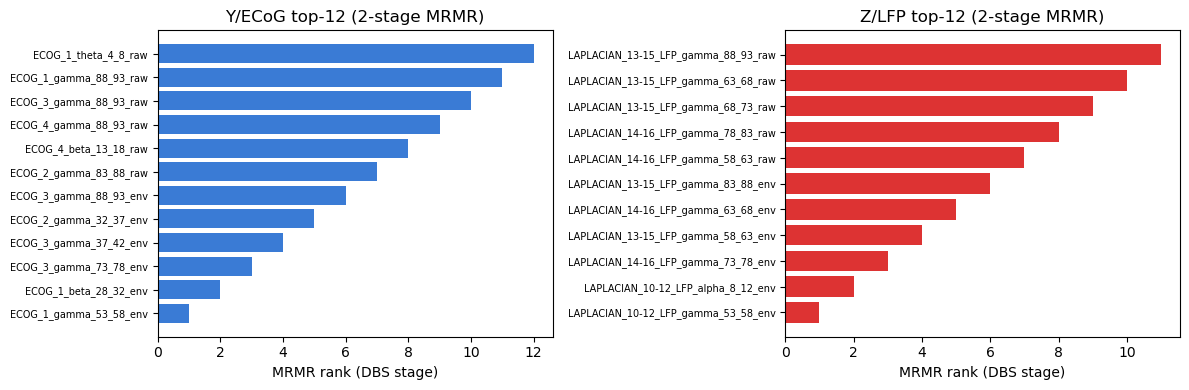

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, max(4, max(K_Y, K_Z) * 0.22)))
axes[0].barh(
    range(len(selected_y))[::-1], range(len(selected_y), 0, -1), color="#3a7bd5"
)
axes[0].set_yticks(range(len(selected_y))[::-1])
axes[0].set_yticklabels(selected_y, fontsize=7)
axes[0].set_xlabel("MRMR rank (DBS stage)")
axes[0].set_title(f"Y/ECoG top-{K_Y} (2-stage MRMR)")

axes[1].barh(range(len(selected_z))[::-1], range(len(selected_z), 0, -1), color="#d33")
axes[1].set_yticks(range(len(selected_z))[::-1])
axes[1].set_yticklabels(selected_z, fontsize=7)
axes[1].set_xlabel("MRMR rank (DBS stage)")
axes[1].set_title(f"Z/LFP top-{K_Z} (2-stage MRMR)")
fig.tight_layout()
plt.show()

## PSID training

PSID accepts list-of-trials directly — no concat needed. Each trial is one
epoch, block-aware via the precomputed split. Z-scoring/mean removal handled
internally by upstream `PSID.PSID` (defaults `zscore_Y=True, zscore_Z=True`),
so we don't pre-zscore.

`fit_Cz_via_KF` choices (upstream PSID kwarg):
  - `True`  → fit Cz by regressing Z onto Kalman-predicted state Xp_KF.
              Closer to deployment behaviour (Z predictions use same Xp).
  - `False` → fit Cz by regressing Z onto smoothed/non-KF state estimate.
              Tighter fit on training set but can mis-generalize at inference.
`True` is the pipeline production default.

In [ ]:
Y_train = [t["Y"][:, sel_y_idx] for t in train_trials]
Z_train = [t["Z"][:, sel_z_idx] for t in train_trials]
Y_val = [t["Y"][:, sel_y_idx] for t in val_trials]
Z_val = [t["Z"][:, sel_z_idx] for t in val_trials]
Y_test = [t["Y"][:, sel_y_idx] for t in test_trials]
Z_test = [t["Z"][:, sel_z_idx] for t in test_trials]

: 

### Why nx → forecast, n1 → classification

PSID's state has block structure: `x_t = [x1; x2]` with `x1 ∈ R^{n1}` the
behavior-relevant subspace and `x2 ∈ R^{nx-n1}` the residual Y subspace.
The system matrices factor as:

```
  A = [[A11, A12],
       [ 0,  A22]]            x1 evolves coupled with x2; x2 is autonomous
  z_t = Cz · x_t = [Cz1, 0] · x_t   ⇒  Z depends only on x1
  y_t = C  · x_t = [C1,  C2]· x_t   ⇒  Y uses both
```

By construction, stage-1 PSID picks `x1` to maximize Z-predictability from
the Y subspace. Stage-2 fills `x2` with whatever Y dynamics remain after
the Z-projection. So:

- **n1 → DBS classification**. When Z correlates with DBS state (Z=lap or
  Z=behavior tracks DBS), `x1` ends up containing the DBS-modulated
  directions of Y. LDA on Xp picks them up. Larger n1 = richer Z-aligned
  subspace = better BA. Tiny n1 (1–4) under-resolves the DBS signature.
- **nx − n1 → Y forecast**. `x2` captures Y's stationary autoregressive
  structure (oscillations, envelopes). Larger n2 = more Y modes available
  for `A^t` to extrapolate.
- Yes, the **classifier sees the full Xp (all nx dims)**, but PSID's
  construction guarantees `x2 ⊥ Z`. If DBS information lives only in Z's
  span (which is what the data suggests), then `x2` carries little extra
  class info; n1 is the load-bearing dimension for BA.

Two-objective sweep:
  1. **nx**: pick by val Y forecast r (plateau-stop). Trade between
     under-fitting Y and overfitting noise.
  2. **n1** (given nx): pick by val LDA BA on Xp, full-grid argmax —
     because BA can dip near 0.5 at small n1 then peak at n1≈10–30.
  3. **MAX_EIG** (given nx, n1): post-hoc clip sweep maximizing val Y
     forecast r (no upstream re-fit; just A clip + DARE refit).

Sani et al. (2021) protocol distinguishes two estimates:

**nx** (total neural dim) — fit SID (= PSID with `n1=0`) on train, predict
Y on val, compute Pearson r per Y channel averaged across channels (= CC).
Pick max-CC nx. Sani uses k-fold CV + 1-sem parsimony rule; we use
single val fold + max-CC for speed (caveat noted).

**n1** (behaviour-relevant dim) — given chosen nx, fit PSID(nx, n1) on
train, predict Z on val, compute per-Z-channel Pearson r averaged. Pick
max-CC n1.

Both rules use Z (not Y) decoding only at the n1 stage — n1 is supervised.
Y self-prediction is a generative-fit criterion at the nx stage.

In [ ]:
def _avg_per_channel_cc(true_list, pred_list):
    """Pearson per channel (mean across trials), then mean across channels.
    Matches Sani's "CC averaged across behavior dimensions" exactly.
    """
    per_trial, _ = pearson_r_per_channel(true_list, pred_list)
    arr = np.array([list(r) for r in per_trial], dtype=float)
    ch_means = np.nanmean(arr, axis=0)
    return float(np.nanmean(ch_means))


def fit_psid_one(Y_tr, Z_tr, nx, n1, i, ws=None):
    """Fit + clip + DARE refit + Cz refit. Returns (wrapped_model, ws).

    Pass `ws` from previous call on same data to reuse upstream PSID's cached
    block-Hankel matrices and SVDs (Yp, ZHat_U/S, YHat_U/S). Upstream
    invalidates stage-2 cache when n1 changes (PSID.py line 363).

    `fit_Cz_via_KF=False` upstream — gives us the GOOD LS-on-Xk Cz unaffected
    by the broken DARE inside upstream's LSSM constructor. After our own DARE
    refit (with valid K), we re-run `fitCzViaKFRegression` so Cz is fit on the
    Kalman-predicted state we'll use at inference (matching the original
    `fit_Cz_via_KF=True` semantics, but with valid K).
    """
    try:
        idSys, ws_out = PSID.PSID(
            Y_tr,
            Z_tr if n1 > 0 else None,
            nx=nx,
            n1=n1,
            i=i,
            time_first=True,
            fit_Cz_via_KF=False,  # skip upstream's broken Cz refit
            WS=ws if ws is not None else dict(),
            return_WS=True,
        )
        idSys.A = PSIDWrapper._clip_A_eigenvalues(np.asarray(idSys.A), MAX_EIG)
        PSIDWrapper._refit_dare_if_needed(idSys, force=True)
        # Optional: re-fit Cz on Kalman-predicted state (matches upstream
        # fit_Cz_via_KF=True intent, but on valid post-clip K).
        if (
            (not SKIP_CZ_KALMAN_REFIT)
            and Z_tr is not None
            and n1 > 0
            and not np.any(np.isnan(idSys.K))
        ):
            try:
                idSys.Cz = fitCzViaKFRegression(idSys, Y_tr, Z_tr, time_first=True)
            except Exception as e:
                print(f"    Cz refit skipped nx={nx} n1={n1}: {e}")
        PSIDWrapper._cache_A_powers(idSys)
        return PSIDWrapper.from_idsys(idSys), ws_out
    except Exception as e:
        print(f"    fit failed nx={nx} n1={n1}: {e}")
        return None, ws


def _pick_parsimony(results, tol, fallback):
    """Smallest grid key whose CC is within `tol` of running max.
    Returns `fallback` if all results are NaN.
    """
    valid = [(k, v) for k, v in sorted(results.items()) if not np.isnan(v)]
    if not valid:
        print(f"  all CCs NaN → fallback to {fallback}")
        return fallback
    best = max(v for _, v in valid)
    for k, v in valid:
        if v >= best - tol:
            return k
    return valid[0][0]


def sweep_with_early_stop(grid, fit_predict_cc, label, tol):
    results = {}
    running_max = -np.inf
    for k in sorted(grid):
        cc = fit_predict_cc(k)
        results[k] = cc
        marker = ""
        if not np.isnan(cc):
            if cc > running_max:
                running_max = cc
            elif cc < running_max - tol:
                results[k] = cc
                marker = "  (plateau — stop)"
                print(f"  {label}={k:3d}  CC = {cc:.4f}{marker}")
                break
        print(f"  {label}={k:3d}  CC = {cc:.4f}{marker}")
    return results


def _val_forecast_avg_r(model, Y_split, Z_split, h_samples, m_samples, target):
    """Mean per-trial-feat Pearson r over val forecasts (target='Y' or 'Z')."""
    true_list, pred_list = [], []
    for Y, Z in zip(Y_split, Z_split):
        if Y.shape[0] < h_samples + m_samples:
            continue
        Zf, Yf, _ = model.forecast(m_samples, Y[:h_samples])
        if target == "Y":
            true_list.append(Y[h_samples : h_samples + m_samples])
            pred_list.append(Yf)
        else:
            true_list.append(Z[h_samples : h_samples + m_samples])
            pred_list.append(Zf)
    if not true_list:
        return float("nan")
    _, r = pearson_r_per_channel(true_list, pred_list)
    return r


if USE_CV_SELECTION:
    h_samp = int(HISTORY_S * SFREQ)
    m_samp = int(FORECAST_S * SFREQ)

    # --- nx sweep ---
    metric_label_nx = "Y self-pred CC" if SELECTION_BY == "cc_pred" else "Y forecast r"
    print(f"nx sweep (n1=0, SID, val {metric_label_nx}, plateau_tol={PLATEAU_TOL}):")
    ws_sid = dict()

    def _nx_cc(nx):
        global ws_sid
        m, ws_sid = fit_psid_one(Y_train, None, nx, 0, I_HORIZON, ws_sid)
        if m is None:
            return float("nan")
        if SELECTION_BY == "cc_pred":
            _, Yp_cv, _ = m.predict(Y_val)
            return _avg_per_channel_cc(Y_val, Yp_cv)
        return _val_forecast_avg_r(m, Y_val, Z_val, h_samp, m_samp, target="Y")

    nx_results = sweep_with_early_stop(NX_GRID, _nx_cc, "nx", PLATEAU_TOL)
    NX = _pick_parsimony(nx_results, PLATEAU_TOL, NX_FALLBACK)
    cc_str = (
        f"{nx_results[NX]:.4f}"
        if NX in nx_results and not np.isnan(nx_results.get(NX, np.nan))
        else "fallback"
    )
    print(f"chosen nx = {NX}  (val {metric_label_nx} = {cc_str})")

    # --- n1 sweep ---
    # When SELECTION_BY="forecast_pearson", n1 picks by val LDA balanced
    # accuracy on Xp epochs (DBS classification) — research goal. Otherwise
    # by Z 1-step CC. Since our actual aim is DBS state inference, BA-driven
    # n1 selection avoids the degenerate forecast-only optimum (n1=2).
    n1_grid = [n for n in N1_GRID if 0 < n <= NX]
    metric_label_n1 = (
        "Z decoding CC" if SELECTION_BY == "cc_pred" else "LDA BA on Xp val"
    )
    print(f"n1 sweep (nx={NX}, val {metric_label_n1}, plateau_tol={PLATEAU_TOL}):")
    ws_psid = dict()

    def _ba_on_xp_val(model):
        Xp_tr_list = model.predict(Y_train)[2]
        Xp_va_list = model.predict(Y_val)[2]
        ep_len_v = int(EPOCH_LEN_S * SFREQ)
        step_v = max(1, int(ep_len_v * (1 - EPOCH_OVERLAP)))

        def _epochs(Xp_list, dicts):
            X, y = [], []
            for Xp, td in zip(Xp_list, dicts):
                if Xp is None:
                    continue
                Xp = np.asarray(Xp)
                T = Xp.shape[0]
                if T < ep_len_v:
                    continue
                lab = 1 if td["stim"] == "on" else 0
                for s in range(0, T - ep_len_v + 1, step_v):
                    X.append(Xp[s : s + ep_len_v].mean(axis=0))
                    y.append(lab)
            return np.asarray(X), np.asarray(y)

        X_tr, y_tr = _epochs(Xp_tr_list, train_trials)
        X_va, y_va = _epochs(Xp_va_list, val_trials)
        if len(X_tr) == 0 or len(X_va) == 0 or len(set(y_va)) < 2:
            return float("nan")
        sc = StandardScaler().fit(X_tr)
        clf = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
        clf.fit(sc.transform(X_tr), y_tr)
        y_pred = clf.predict(sc.transform(X_va))
        return float(balanced_accuracy_score(y_va, y_pred))

    def _n1_cc(n1):
        global ws_psid
        m, ws_psid = fit_psid_one(Y_train, Z_train, NX, n1, I_HORIZON, ws_psid)
        if m is None:
            return float("nan")
        if SELECTION_BY == "cc_pred":
            Zp_cv, _, _ = m.predict(Y_val)
            return _avg_per_channel_cc(Z_val, Zp_cv)
        return _ba_on_xp_val(m)

    if SELECTION_BY == "cc_pred":
        # CC-based n1 picks via plateau parsimony (monotone curve).
        n1_results = sweep_with_early_stop(n1_grid, _n1_cc, "n1", PLATEAU_TOL)
        N1 = _pick_parsimony(n1_results, PLATEAU_TOL, min(N1_FALLBACK, NX))
    else:
        # BA-driven n1: BA is non-monotone (can dip near 0.5 at n1=2 then peak
        # at n1=20+). Plateau-stop fires too early. Run the FULL grid and
        # argmax BA. Print every value for visibility.
        n1_results: dict[int, float] = {}
        for n1 in sorted(n1_grid):
            t0 = time.time()
            cc = _n1_cc(n1)
            dt = time.time() - t0
            n1_results[n1] = cc
            print(f"  n1={n1:3d}  BA = {cc:.4f}  ({dt:.1f}s)")
        valid = [(k, v) for k, v in n1_results.items() if not np.isnan(v)]
        N1 = max(valid, key=lambda kv: kv[1])[0] if valid else min(N1_FALLBACK, NX)
    cc_str = (
        f"{n1_results[N1]:.4f}"
        if N1 in n1_results and not np.isnan(n1_results.get(N1, np.nan))
        else "fallback"
    )
    print(f"chosen n1 = {N1}  (val {metric_label_n1} = {cc_str})")
else:
    NX, N1 = NX_FALLBACK, N1_FALLBACK
    print(f"USE_CV_SELECTION=False → fallback elbow yaml: nx={NX}  n1={N1}")

nx sweep (n1=0, SID, val Y forecast r, plateau_tol=0.005):
Could not solve DARE: Matrix e should be square.


2026-05-01 11:40:26,010 - default - INFO - Structured log file: /home/bobby/repos/latent-neural-dynamics-modeling/logs/default_20260501_114026.md
2026-05-01 11:40:26,011 - default - INFO - Console mirror file: /home/bobby/repos/latent-neural-dynamics-modeling/logs/default_20260501_114026.console.log


  nx= 50  CC = 0.1234
chosen nx = 50  (val Y forecast r = 0.1234)
n1 sweep (nx=50, val LDA BA on Xp val, plateau_tol=0.005):


In [ ]:
# Final fit at chosen (nx, n1) on full train.
idSys, ws = PSID.PSID(
    Y_train,
    Z_train,
    nx=NX,
    n1=N1,
    i=I_HORIZON,
    time_first=True,
    fit_Cz_via_KF=False,  # bypass upstream's broken Cz-via-Kalman path
    return_WS=True,
)
idSys.ZHat_S = ws.get("ZHat_S")
idSys.YHat_S = ws.get("YHat_S")

# MAX_EIG grid search — pick clip that maximizes val Y forecast r.
# Each candidate clones idSys, applies clip + DARE refit on a copy of the
# upstream A, evaluates val Y forecast r. Cheap because no full refit.
MAX_EIG_GRID = [0.99, 0.996, 0.999, 0.9999, 0.99999, 0.999999]
A_orig = np.asarray(idSys.A).copy()
h_samp_eig = int(HISTORY_S * SFREQ)
m_samp_eig = int(FORECAST_S * SFREQ)

print(f"\nMAX_EIG grid sweep (val Y fcst r):")
best_max_eig, best_r = None, -np.inf
for me in MAX_EIG_GRID:
    cand = copy.deepcopy(idSys)
    cand.A = PSIDWrapper._clip_A_eigenvalues(A_orig, me)
    PSIDWrapper._refit_dare_if_needed(cand, force=True)
    PSIDWrapper._cache_A_powers(cand)
    if np.any(np.isnan(getattr(cand, "K", np.asarray([])))):
        print(f"  MAX_EIG={me:.6f}  K=NaN (DARE failed) — skip")
        continue
    wrap = PSIDWrapper.from_idsys(cand)
    val_r = _val_forecast_avg_r(wrap, Y_val, Z_val, h_samp_eig, m_samp_eig, "Y")
    print(f"  MAX_EIG={me:.6f}  val Y fcst r = {val_r:.4f}")
    if not np.isnan(val_r) and val_r > best_r:
        best_r, best_max_eig = val_r, me

if best_max_eig is None:
    best_max_eig = MAX_EIG  # fallback to default
print(f"chosen MAX_EIG = {best_max_eig}  (val Y fcst r = {best_r:.4f})")
MAX_EIG = best_max_eig

# Apply the chosen clip + DARE refit to the live model.
idSys.A = PSIDWrapper._clip_A_eigenvalues(A_orig, MAX_EIG)
PSIDWrapper._refit_dare_if_needed(idSys, force=True)
# Optionally re-fit Cz on Kalman-predicted state with valid K.
if (not SKIP_CZ_KALMAN_REFIT) and N1 > 0 and not np.any(np.isnan(idSys.K)):
    idSys.Cz = fitCzViaKFRegression(idSys, Y_train, Z_train, time_first=True)
PSIDWrapper._cache_A_powers(idSys)
if np.any(np.isnan(getattr(idSys, "K", np.asarray([])))):
    print("WARNING: idSys.K contains NaN — Zp will be constant (DARE failed).")

A_eigs = np.linalg.eigvals(idSys.A)
print(
    f"trained PSID  nx={NX} n1={N1} i={I_HORIZON}  "
    f"max|eig(A)|={np.max(np.abs(A_eigs)):.4f}"
)

psid_model = PSIDWrapper.from_idsys(idSys)

### Singular spectra (informs nx/n1 elbow choice)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, S, ttl in (
    (axes[0], idSys.ZHat_S, "Stage-1 ZHat (behaviour-relevant)"),
    (axes[1], idSys.YHat_S, "Stage-2 YHat (residual)"),
):
    if S is None:
        ax.set_visible(False)
        continue
    ax.plot(np.arange(1, len(S) + 1), S, marker="o", ms=3, color="#3a7bd5")
    ax.set_xlabel("singular index")
    ax.set_ylabel("singular value")
    ax.set_title(ttl, fontsize=10)
fig.tight_layout()
plt.show()

## One-step prediction (val + test)

In [ ]:
def sani_cc(true_list, pred_list):
    """Sani et al. CC, per-feature flavor: concat all trials' samples per
    feature (mRMR-selected band×electrode column) → 1 Pearson r per feature
    → mean across features. We feed PSID a *pool* of K_Y=K_Z=8 selected
    features, not raw channels — so "per feature" is the relevant axis.

    Differs from ``pearson_r_per_channel`` which means over (trial, feature)
    pairs (each trial contributes its own r). CC pools temporal samples
    across trials *before* correlating → captures feature-level fit, not
    trial-to-trial variability.
    """
    if not true_list:
        return float("nan"), []
    true_cat = np.concatenate(true_list, axis=0)
    pred_cat = np.concatenate(pred_list, axis=0)
    n_feat = true_cat.shape[1]
    rs = []
    for c in range(n_feat):
        t = true_cat[:, c]
        p = pred_cat[:, c]
        if np.std(t) < 1e-12 or np.std(p) < 1e-12:
            continue
        r = np.corrcoef(t, p)[0, 1]
        if np.isfinite(r):
            rs.append(r)
    return (float(np.mean(rs)) if rs else float("nan")), rs


Zp_tr, Yp_tr, Xp_tr = psid_model.predict(Y_train)
Zp_val, Yp_val, Xp_val = psid_model.predict(Y_val)
Zp_te, Yp_te, Xp_te = psid_model.predict(Y_test)

# Two-flavor metric:
#   r_*    : pearson_r_per_channel — mean over (trial, channel) pairs.
#   cc_*   : Sani et al. CC — concat trials per channel, 1 r per channel,
#            mean across channels. CC pools temporal samples before
#            correlating, so it represents channel-level fit not trial noise.
_, r_y_val = pearson_r_per_channel(Y_val, Yp_val)
_, r_y_te = pearson_r_per_channel(Y_test, Yp_te)
_, r_z_val = pearson_r_per_channel(Z_val, Zp_val)
_, r_z_te = pearson_r_per_channel(Z_test, Zp_te)
cc_y_val, _ = sani_cc(Y_val, Yp_val)
cc_y_te, _ = sani_cc(Y_test, Yp_te)
cc_z_val, _ = sani_cc(Z_val, Zp_val)
cc_z_te, _ = sani_cc(Z_test, Zp_te)

# Diagnose: when Zp std ~ 0, ECoG→LFP cross-decoding collapsed (PSID stage-1
# found Z unobservable from Y). Per-channel std in original units.
zp_std_te = np.mean([np.std(z, axis=0) for z in Zp_te], axis=0)
zt_std_te = np.mean([np.std(z, axis=0) for z in Z_test], axis=0)
print(
    f"val   Y-pred  r = {r_y_val:.4f}  CC = {cc_y_val:.4f}    Z-pred  r = {r_z_val:.4f}  CC = {cc_z_val:.4f}"
)
print(
    f"test  Y-pred  r = {r_y_te:.4f}  CC = {cc_y_te:.4f}    Z-pred  r = {r_z_te:.4f}  CC = {cc_z_te:.4f}"
)
print(f"test Zp std/Z std ratio: {(zp_std_te / np.maximum(zt_std_te, 1e-12)).round(3)}")

### Per-channel Pearson r (test split)

In [ ]:
r_y_per_ch_te, _ = pearson_r_per_channel(Y_test, Yp_te)
r_z_per_ch_te, _ = pearson_r_per_channel(Z_test, Zp_te)
r_y_means = np.nanmean(np.array([list(r) for r in r_y_per_ch_te], dtype=float), axis=0)
r_z_means = np.nanmean(np.array([list(r) for r in r_z_per_ch_te], dtype=float), axis=0)

fig, axes = plt.subplots(
    1, 2, figsize=(12, max(3, max(len(selected_y), len(selected_z)) * 0.22))
)
axes[0].barh(range(len(selected_y))[::-1], r_y_means, color="#3a7bd5")
axes[0].axvline(0, color="k", lw=0.5)
axes[0].set_yticks(range(len(selected_y))[::-1])
axes[0].set_yticklabels(selected_y, fontsize=7)
axes[0].set_xlabel("mean Pearson r (test)")
axes[0].set_title("Y reconstruction (ECoG)")

axes[1].barh(range(len(selected_z))[::-1], r_z_means, color="#d33")
axes[1].axvline(0, color="k", lw=0.5)
axes[1].set_yticks(range(len(selected_z))[::-1])
axes[1].set_yticklabels(selected_z, fontsize=7)
axes[1].set_xlabel("mean Pearson r (test)")
axes[1].set_title("Z cross-decoding (LFP)")
fig.tight_layout()
plt.show()

### Example trial — true vs predicted (test trial 0)

Top row(s): Y/ECoG channels — what PSID self-predicts via `(A, C)`.
Bottom row(s): Z/LFP (or Z=Y) channels — predicted via `Cz`.

In [ ]:
def plot_pred_panel(true_arr, pred_arr, names, sfreq, color, title, n_show=None):
    if n_show is None:
        n_show = true_arr.shape[1]
    fig, axes = plt.subplots(n_show, 1, figsize=(8, 1.4 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    t_axis = np.arange(true_arr.shape[0]) / sfreq
    for ax, ch_idx in zip(axes, range(n_show)):
        ax.plot(t_axis, true_arr[:, ch_idx], color="k", lw=1, label="true")
        ax.plot(t_axis, pred_arr[:, ch_idx], color=color, lw=1, label="pred")
        ax.set_ylabel(names[ch_idx], fontsize=7)
        if ch_idx == 0:
            ax.legend(loc="best", fontsize=8)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    plt.show()


trial0 = test_trials[0]
trial_tag = f"test trial b{trial0['block']} t{trial0['trial']} (stim={trial0['stim']})"
plot_pred_panel(
    Y_test[0],
    Yp_te[0],
    selected_y,
    SFREQ,
    "#3a7bd5",
    f"Y/ECoG self-prediction — {trial_tag}",
)
plot_pred_panel(
    Z_test[0], Zp_te[0], selected_z, SFREQ, "#d33", f"Z reconstruction — {trial_tag}"
)

## Multi-step forecast

Per trial: feed `HISTORY_S` of past Y, forecast `FORECAST_S` ahead. Compare
`Yf` to true future on the same window. Z forecast comes for free via the
learned `Cz`.

In [ ]:
m = int(FORECAST_S * SFREQ)
h = int(HISTORY_S * SFREQ)


def forecast_split(Y_split, Z_split, h, m, psid_model):
    out = {"Yf": [], "Zf": [], "Xf": [], "Y_true": [], "Z_true": []}
    for Y, Z in zip(Y_split, Z_split):
        if Y.shape[0] < h + m:
            continue
        Zf, Yf, Xf = psid_model.forecast(m, Y[:h])
        out["Yf"].append(Yf)
        out["Zf"].append(Zf)
        out["Xf"].append(Xf)
        out["Y_true"].append(Y[h : h + m])
        out["Z_true"].append(Z[h : h + m])
    return out


fc_val = forecast_split(Y_val, Z_val, h, m, psid_model)
fc_te = forecast_split(Y_test, Z_test, h, m, psid_model)

_, r_yf_val = pearson_r_per_channel(fc_val["Y_true"], fc_val["Yf"])
_, r_yf_te = pearson_r_per_channel(fc_te["Y_true"], fc_te["Yf"])
_, r_zf_val = pearson_r_per_channel(fc_val["Z_true"], fc_val["Zf"])
_, r_zf_te = pearson_r_per_channel(fc_te["Z_true"], fc_te["Zf"])
cc_yf_val, _ = sani_cc(fc_val["Y_true"], fc_val["Yf"])
cc_yf_te, _ = sani_cc(fc_te["Y_true"], fc_te["Yf"])
cc_zf_val, _ = sani_cc(fc_val["Z_true"], fc_val["Zf"])
cc_zf_te, _ = sani_cc(fc_te["Z_true"], fc_te["Zf"])

print(f"forecast {FORECAST_S:.1f}s  history {HISTORY_S:.1f}s")
print(
    f"val   Y-fcst  r = {r_yf_val:.4f}  CC = {cc_yf_val:.4f}    Z-fcst  r = {r_zf_val:.4f}  CC = {cc_zf_val:.4f}"
)
print(
    f"test  Y-fcst  r = {r_yf_te:.4f}  CC = {cc_yf_te:.4f}    Z-fcst  r = {r_zf_te:.4f}  CC = {cc_zf_te:.4f}"
)


def per_horizon_pearson(true_list, pred_list):
    """Per-step Pearson r averaged across channels and trials.
    Each entry in lists has shape (m, n_ch). Returns array of length m.
    """
    m = true_list[0].shape[0]
    n_ch = true_list[0].shape[1]
    rs = np.full(m, np.nan)
    for k in range(m):
        true_k = np.array([t[k, :] for t in true_list])  # (n_trials, n_ch)
        pred_k = np.array([p[k, :] for p in pred_list])
        ch_rs = []
        for c in range(n_ch):
            tk = true_k[:, c]
            pk = pred_k[:, c]
            if np.std(tk) < 1e-12 or np.std(pk) < 1e-12:
                continue
            r = np.corrcoef(tk, pk)[0, 1]
            if np.isfinite(r):
                ch_rs.append(r)
        if ch_rs:
            rs[k] = float(np.mean(ch_rs))
    return rs


def per_horizon_rmse(true_list, pred_list):
    """Per-step RMSE averaged across channels and trials. Z-scores per
    channel (using true std on test) so RMSE is dimensionless / comparable
    across bands. Returns array of length m.
    """
    m = true_list[0].shape[0]
    n_ch = true_list[0].shape[1]
    # per-channel std across all (trial, time) for normalization
    all_true = np.concatenate(true_list, axis=0)
    ch_std = all_true.std(axis=0)
    rmses = np.full(m, np.nan)
    for k in range(m):
        true_k = np.array([t[k, :] for t in true_list])
        pred_k = np.array([p[k, :] for p in pred_list])
        sq = (true_k - pred_k) ** 2  # (n_trials, n_ch)
        per_ch_rmse = np.sqrt(sq.mean(axis=0))
        norm = per_ch_rmse / np.maximum(ch_std, 1e-12)
        rmses[k] = float(np.nanmean(norm))
    return rmses


def per_horizon_r2(true_list, pred_list):
    """Per-step R² per feature, mean across features.

    R²_k,c = 1 − Σ_trials (y_{trial,k,c} − ŷ_{trial,k,c})²
                / Σ_trials (y_{trial,k,c} − ȳ_{k,c})²
    where ȳ_{k,c} = mean across trials at horizon k for feature c.

    Penalizes scale + bias drift; Pearson r misses both. Negative R² →
    forecast worse than horizon-mean baseline. Returns array of length m.
    """
    m = true_list[0].shape[0]
    r2s = np.full(m, np.nan)
    for k in range(m):
        true_k = np.array([t[k, :] for t in true_list])  # (n_trials, n_ch)
        pred_k = np.array([p[k, :] for p in pred_list])
        ch_mean_k = true_k.mean(axis=0)  # (n_ch,)
        ss_res = ((true_k - pred_k) ** 2).sum(axis=0)  # (n_ch,)
        ss_tot = ((true_k - ch_mean_k) ** 2).sum(axis=0)  # (n_ch,)
        with np.errstate(divide="ignore", invalid="ignore"):
            r2 = 1.0 - ss_res / np.where(ss_tot > 1e-12, ss_tot, np.nan)
        r2s[k] = float(np.nanmean(r2))
    return r2s


def state_norm_trajectory(Xf_list):
    """||x_t||₂ / ||x_0||₂ averaged across forecasts. Stable A → decay; if
    growing or oscillating, A modes near unit circle are problematic.
    Each Xf is (m, nx). Returns array of length m.
    """
    if not Xf_list:
        return np.array([])
    m = Xf_list[0].shape[0]
    norms = np.zeros((len(Xf_list), m))
    for i, Xf in enumerate(Xf_list):
        Xf = np.asarray(Xf)
        x0_norm = np.linalg.norm(Xf[0]) + 1e-12
        for k in range(m):
            norms[i, k] = np.linalg.norm(Xf[k]) / x0_norm
    return norms.mean(axis=0)


# Targets: forecast r ≥ 0.5 in first ~0.1 s, ≥ 0.1–0.2 overall.
y_pearson_te = per_horizon_pearson(fc_te["Y_true"], fc_te["Yf"])
z_pearson_te = per_horizon_pearson(fc_te["Z_true"], fc_te["Zf"])
y_rmse_te = per_horizon_rmse(fc_te["Y_true"], fc_te["Yf"])
z_rmse_te = per_horizon_rmse(fc_te["Z_true"], fc_te["Zf"])
y_r2_te = per_horizon_r2(fc_te["Y_true"], fc_te["Yf"])
z_r2_te = per_horizon_r2(fc_te["Z_true"], fc_te["Zf"])
xf_norm_te = state_norm_trajectory(fc_te["Xf"])

# A-eigenvalue stability snapshot
A_eigs_final = np.linalg.eigvals(idSys.A)
print(
    f"\nstability:  max|eig(A)| = {np.max(np.abs(A_eigs_final)):.4f}  "
    f"# complex pairs = {int(np.sum(np.abs(A_eigs_final.imag) > 1e-9) / 2)}  "
    f"# near-unit (|e|>0.99) = {int(np.sum(np.abs(A_eigs_final) > 0.99))}"
)
print(f"\nper-horizon test forecast (m={m} steps = {FORECAST_S:.1f}s):")
print(
    "  step | t (s) | Y r    | Z r    | Y R²    | Z R²    | Y rmse | Z rmse | ||Xf||/||X0||"
)
for k in range(m):
    print(
        f"  {k+1:4d} | {(k+1)/SFREQ:5.3f} | "
        f"{y_pearson_te[k]:+.3f} | {z_pearson_te[k]:+.3f} | "
        f"{y_r2_te[k]:+.3f} | {z_r2_te[k]:+.3f} | "
        f"{y_rmse_te[k]:.3f}  | {z_rmse_te[k]:.3f}  | "
        f"{xf_norm_te[k]:.3f}"
    )
n_first = max(1, int(0.1 * SFREQ))
print(f"\n  first 0.1 s mean Y r = {np.nanmean(y_pearson_te[:n_first]):.3f}")
print(f"  first 0.1 s mean Z r = {np.nanmean(z_pearson_te[:n_first]):.3f}")
print(f"  full {FORECAST_S:.1f}s mean Y r = {np.nanmean(y_pearson_te):.3f}")
print(f"  full {FORECAST_S:.1f}s mean Z r = {np.nanmean(z_pearson_te):.3f}")
print(f"  full {FORECAST_S:.1f}s mean Y rmse = {np.nanmean(y_rmse_te):.3f}")
print(f"  full {FORECAST_S:.1f}s mean Z rmse = {np.nanmean(z_rmse_te):.3f}")

### Forecast Pearson r + RMSE over horizon (test)

In [ ]:
fig, (ax_r, ax_e) = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
t_axis = (np.arange(m) + 1) / SFREQ
ax_r.plot(t_axis, y_pearson_te, color="#3a7bd5", marker="o", ms=3, label="Y")
ax_r.plot(t_axis, z_pearson_te, color="#d33", marker="o", ms=3, label="Z")
ax_r.axhline(0.5, color="0.5", ls=":", lw=0.8)
ax_r.axhline(0.0, color="k", lw=0.5)
ax_r.set_xlabel("forecast horizon (s)")
ax_r.set_ylabel("Pearson r")
ax_r.set_title("test forecast r over horizon")
ax_r.legend(loc="best", fontsize=9)

ax_e.plot(t_axis, y_rmse_te, color="#3a7bd5", marker="o", ms=3, label="Y")
ax_e.plot(t_axis, z_rmse_te, color="#d33", marker="o", ms=3, label="Z")
ax_e.axhline(1.0, color="0.5", ls=":", lw=0.8)
ax_e.set_xlabel("forecast horizon (s)")
ax_e.set_ylabel("normalized RMSE (per-channel)")
ax_e.set_title("test forecast RMSE over horizon")
ax_e.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

# Save figure + per-horizon metrics for headless / chained runs.
fig_dir = PROJECT_ROOT / "results" / "simplified_pipeline"
fig_dir.mkdir(parents=True, exist_ok=True)
tag = f"{PARTICIPANT}_S{SESSION}_Z={Z_SOURCE}_Y={Y_SOURCE}"
fig.savefig(fig_dir / f"forecast_horizon_{tag}.png", dpi=120)
np.savez(
    fig_dir / f"forecast_horizon_{tag}.npz",
    t_axis=t_axis,
    y_pearson=y_pearson_te,
    z_pearson=z_pearson_te,
    y_rmse=y_rmse_te,
    z_rmse=z_rmse_te,
)
print(f"saved {fig_dir / f'forecast_horizon_{tag}.png'}")

### Forecast example (test trial 0)

Past (`HISTORY_S` s): true. Future (`FORECAST_S` s): true (dashed) vs
forecast (solid). One panel-set for Y, one for Z.

In [ ]:
def plot_forecast_panel(
    full_arr, true_future, pred_future, names, h, m, sfreq, color, title, n_show=None
):
    if n_show is None:
        n_show = full_arr.shape[1]
    fig, axes = plt.subplots(n_show, 1, figsize=(8, 1.4 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    t_past = np.arange(h) / sfreq
    t_fut = np.arange(h, h + m) / sfreq
    for ax, ch_idx in zip(axes, range(n_show)):
        ax.plot(t_past, full_arr[:h, ch_idx], color="k", lw=1, label="past (true)")
        ax.plot(
            t_fut,
            true_future[:, ch_idx],
            color="k",
            lw=1,
            ls="--",
            label="future (true)",
        )
        ax.plot(t_fut, pred_future[:, ch_idx], color=color, lw=1, label="forecast")
        ax.set_ylabel(names[ch_idx], fontsize=7)
        if ch_idx == 0:
            ax.legend(loc="best", fontsize=8)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    plt.show()


trial0 = test_trials[0]
fcst_tag = f"forecast — b{trial0['block']} t{trial0['trial']} (stim={trial0['stim']})"
plot_forecast_panel(
    Y_test[0],
    fc_te["Y_true"][0],
    fc_te["Yf"][0],
    selected_y,
    h,
    m,
    SFREQ,
    "#3a7bd5",
    f"Y/ECoG forecast — {fcst_tag}",
)
plot_forecast_panel(
    Z_test[0],
    fc_te["Z_true"][0],
    fc_te["Zf"][0],
    selected_z,
    h,
    m,
    SFREQ,
    "#d33",
    f"Z forecast — {fcst_tag}",
)

## DBS classification on PSID latents (Xp) — CSP → LDA

Epoch each trial's `Xp` with `EPOCH_LEN_S` windows + `EPOCH_OVERLAP` overlap.
Each epoch is a `(ep_len, nx)` slice of the latent trajectory — kept as a
multivariate time-series, NOT mean-pooled.

Pipeline (`utils/classification/pipeline.create_pipeline`):
  1. transpose → MNE shape `(n_epochs, n_channels, n_samples)`
  2. CSP `n_components=4`, `reg="ledoit_wolf"`, `log=True`
     — finds 4 spatial filters in latent space that maximize the variance
     ratio between DBS classes; outputs log-variance per filter (4 features)
  3. StandardScaler
  4. LDA (default solver, no manual shrinkage)

Compared to the prior mean-pool LDA: latent dim is reduced by CSP (4 << nx)
*before* LDA, so we no longer fit LDA in the full latent space. CSP also uses
*time-series* structure within each epoch (variance of the projected signal),
which mean-pool throws away.

In [ ]:
ep_len = int(EPOCH_LEN_S * SFREQ)
step = max(1, int(ep_len * (1 - EPOCH_OVERLAP)))


def csp_epochs_from_trials(Xp_list, trial_dicts, ep_len, step):
    """Slice each trial's Xp into overlapping (ep_len, nx) chunks.
    Returns X (n_epochs, ep_len, nx), y, groups (block_id, trial_id).
    """
    X_eps, y_eps, groups = [], [], []
    for Xp, td in zip(Xp_list, trial_dicts):
        if Xp is None:
            continue
        Xp = np.asarray(Xp)
        T = Xp.shape[0]
        if T < ep_len:
            continue
        label = 1 if td["stim"] == "on" else 0
        for s in range(0, T - ep_len + 1, step):
            X_eps.append(Xp[s : s + ep_len])
            y_eps.append(label)
            groups.append((td["block"], td["trial"]))
    return np.asarray(X_eps), np.asarray(y_eps), groups


X_fit, y_fit, _ = csp_epochs_from_trials(
    Xp_tr + Xp_val, train_trials + val_trials, ep_len, step
)
X_te, y_te, _ = csp_epochs_from_trials(Xp_te, test_trials, ep_len, step)
print(f"epochs: fit={X_fit.shape}, test={X_te.shape}  (n_epochs, ep_len, nx)")

pipe = create_pipeline(fs=SFREQ)
pipe.fit(X_fit, y_fit)
y_pred = pipe.predict(X_te)
ba = balanced_accuracy_score(y_te, y_pred)
cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
print(f"test balanced accuracy (CSP→LDA): {ba:.4f}")
print(f"confusion matrix [rows=true off/on, cols=pred off/on]:\n{cm}")

### Alt: PCA → LDA

Classical EEG/BCI baseline. Mean-pool per epoch → ``(n_epochs, nx)`` →
StandardScaler → PCA(K) → LDA. Unsupervised dim reduction (variance-based)
guards LDA against high-D overfitting. Compare BA against CSP→LDA above.

In [ ]:
PCA_COMPONENTS = 8

X_fit_mp = X_fit.mean(axis=1)  # (n_epochs, nx) — drops time axis
X_te_mp = X_te.mean(axis=1)

pca_pipe = SkPipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=PCA_COMPONENTS)),
        ("clf", LinearDiscriminantAnalysis()),
    ]
)
pca_pipe.fit(X_fit_mp, y_fit)
y_pred_pca = pca_pipe.predict(X_te_mp)
ba_pca = balanced_accuracy_score(y_te, y_pred_pca)
cm_pca = confusion_matrix(y_te, y_pred_pca, labels=[0, 1])
print(f"test balanced accuracy (PCA({PCA_COMPONENTS})→LDA): {ba_pca:.4f}")
print(f"confusion matrix [rows=true off/on, cols=pred off/on]:\n{cm_pca}")

## Classification on **forecast** latents (Xf)

Goal: forecasts are the primary target — classification on Xf is the
downstream evidence that forecast quality preserves DBS-relevant structure.

Per trial, slide a `(h, m)` window across time at stride `m` (non-overlap).
Each window: feed past `h` to PSID, get `m`-step forecast Xf shape `(m, nx)`.
Stack across trials with class labels → CSP/PCA-LDA on **future** latents.

In [ ]:
FORECAST_STRIDE = m  # non-overlapping forecasts within each trial


def collect_forecast_chunks(Y_split, trial_dicts, h, m, stride, psid_model):
    X_eps, y_eps = [], []
    for Y, td in zip(Y_split, trial_dicts):
        T = Y.shape[0]
        if T < h + m:
            continue
        label = 1 if td["stim"] == "on" else 0
        for s in range(0, T - h - m + 1, stride):
            _, _, Xf_chunk = psid_model.forecast(m, Y[s : s + h])
            X_eps.append(np.asarray(Xf_chunk))
            y_eps.append(label)
    return np.asarray(X_eps), np.asarray(y_eps)


X_fit_xf, y_fit_xf = collect_forecast_chunks(
    Y_train + Y_val, train_trials + val_trials, h, m, FORECAST_STRIDE, psid_model
)
X_te_xf, y_te_xf = collect_forecast_chunks(
    Y_test, test_trials, h, m, FORECAST_STRIDE, psid_model
)
print(f"Xf chunks: fit={X_fit_xf.shape}, test={X_te_xf.shape}  (n_chunks, m, nx)")

# CSP→LDA on Xf
pipe_xf = create_pipeline(fs=SFREQ)
pipe_xf.fit(X_fit_xf, y_fit_xf)
y_pred_xf = pipe_xf.predict(X_te_xf)
ba_xf = balanced_accuracy_score(y_te_xf, y_pred_xf)
cm_xf = confusion_matrix(y_te_xf, y_pred_xf, labels=[0, 1])
print(f"Xf  CSP→LDA  BA = {ba_xf:.4f}")
print(f"Xf  CSP→LDA  CM:\n{cm_xf}")

# PCA(K)→LDA on Xf (mean-pool over forecast horizon)
X_fit_xf_mp = X_fit_xf.mean(axis=1)
X_te_xf_mp = X_te_xf.mean(axis=1)
pca_pipe_xf = SkPipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=PCA_COMPONENTS)),
        ("clf", LinearDiscriminantAnalysis()),
    ]
)
pca_pipe_xf.fit(X_fit_xf_mp, y_fit_xf)
y_pred_xf_pca = pca_pipe_xf.predict(X_te_xf_mp)
ba_xf_pca = balanced_accuracy_score(y_te_xf, y_pred_xf_pca)
cm_xf_pca = confusion_matrix(y_te_xf, y_pred_xf_pca, labels=[0, 1])
print(f"Xf  PCA({PCA_COMPONENTS})→LDA  BA = {ba_xf_pca:.4f}")
print(f"Xf  PCA→LDA  CM:\n{cm_xf_pca}")

### Confusion matrix

In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 3.2))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["off", "on"])
ax.set_yticklabels(["off", "on"])
ax.set_xlabel("pred")
ax.set_ylabel("true")
ax.set_title(f"DBS classification — BA={ba:.3f}")
fig.colorbar(im, ax=ax, fraction=0.045)
fig.tight_layout()
plt.show()

### CSP feature scatter (first 2 components, test set)

Project each test epoch through CSP filters → log-variance features. Plot
epochs in the (CSP-1, CSP-2) plane to see DBS class separation.

In [ ]:
csp_step = pipe.named_steps["csp"]
X_te_mne = pipe.named_steps["transpose"].transform(X_te)
X_te_csp = csp_step.transform(X_te_mne)  # (n_epochs, n_components)
if X_te_csp.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(5, 4))
    for label, color, name in ((0, "#3a7bd5", "off"), (1, "#d33", "on")):
        mask = y_te == label
        if mask.any():
            ax.scatter(
                X_te_csp[mask, 0],
                X_te_csp[mask, 1],
                s=8,
                alpha=0.5,
                color=color,
                label=name,
            )
    ax.legend(loc="best", fontsize=9)
    ax.set_xlabel("CSP-1 (log-var)")
    ax.set_ylabel("CSP-2 (log-var)")
    ax.set_title("test epochs in first 2 CSP components")
    fig.tight_layout()
    plt.show()